In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("WHR2023.csv")

df = df[[
    "Country name",
    "Ladder score",
    "Logged GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]].copy()

df = df.rename(columns={
    "Country name": "Country",
    "Ladder score": "Happiness_Score",
    "Logged GDP per capita": "GDP",
    "Social support": "Social_Support",
    "Healthy life expectancy": "Life_Expectancy",
    "Freedom to make life choices": "Freedom",
    "Generosity": "Generosity",
    "Perceptions of corruption": "Corruption"
})

print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

Dataset: 137 countries, 8 columns
       Country  Happiness_Score     GDP  Social_Support  Life_Expectancy  \
0      Finland            7.804  10.792           0.969           71.150   
1      Denmark            7.586  10.962           0.954           71.250   
2      Iceland            7.530  10.896           0.983           72.050   
3       Israel            7.473  10.639           0.943           72.697   
4  Netherlands            7.403  10.942           0.930           71.550   

   Freedom  Generosity  Corruption  
0    0.961      -0.019       0.182  
1    0.934       0.134       0.196  
2    0.936       0.211       0.668  
3    0.809      -0.023       0.708  
4    0.887       0.213       0.379  


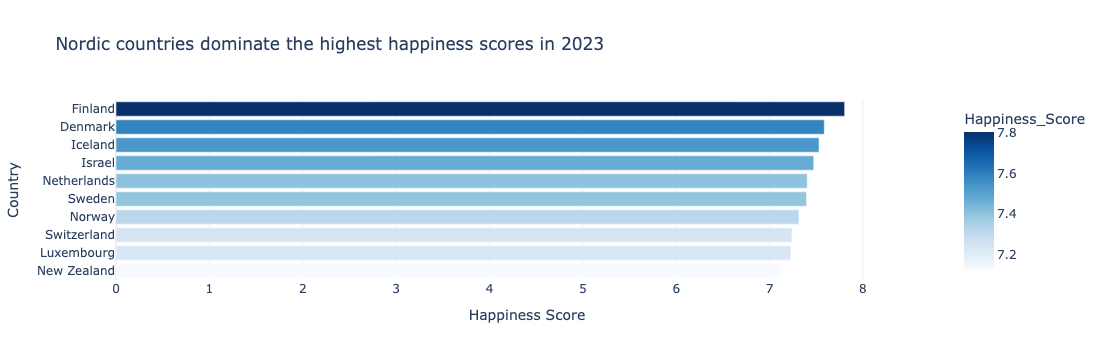

In [3]:
import plotly.express as px

# Top 10 happiest countries
top10 = df.nlargest(10, 'Happiness_Score')

fig = px.bar(
    top10.sort_values('Happiness_Score'),
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Happiness_Score',
    color_continuous_scale='Blues',
    title='Nordic countries dominate the highest happiness scores in 2023'
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Happiness Score',
    yaxis_title='Country'
)

# zero baseline
fig.update_xaxes(range=[0, top10['Happiness_Score'].max() + 1])

fig.show()

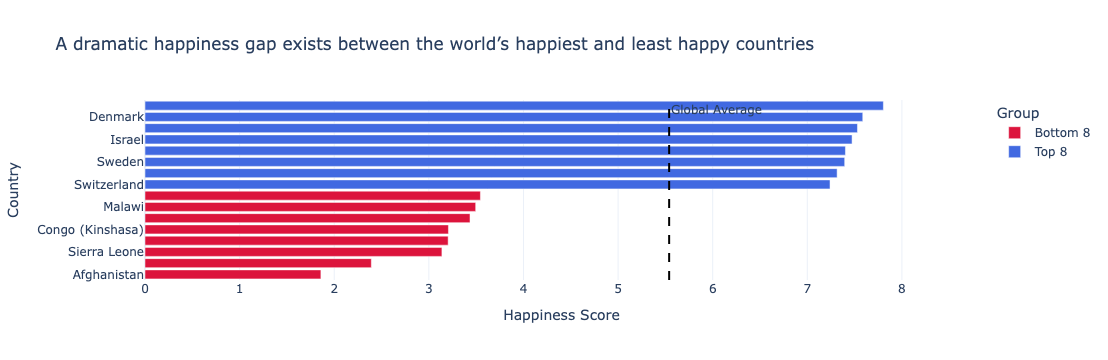

In [4]:
# Task 2

import plotly.express as px
import pandas as pd

# Top 8 happiest countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'

# Bottom 8 least happy countries
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

# Combine datasets
combined = pd.concat([bottom8, top8])

#cleaner chart
combined = combined.sort_values('Happiness_Score')

# Global average
global_avg = df['Happiness_Score'].mean()

# Create chart
fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    color_discrete_map={
        'Top 8': 'royalblue',
        'Bottom 8': 'crimson'
    },
    title='A dramatic happiness gap exists between the world’s happiest and least happy countries'
)

# Add global average line
fig.add_vline(
    x=global_avg,
    line_dash="dash",
    line_color="black",
    annotation_text="Global Average"
)

# Layout improvements
fig.update_layout(
    template='plotly_white',
    xaxis_title='Happiness Score',
    yaxis_title='Country'
)

# Zero baseline
fig.update_xaxes(range=[0, combined['Happiness_Score'].max() + 1])

fig.show()